In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [20]:
# If CSV files are in the project root (climate-challenge-week0/):
df = pd.read_csv("ethiopia.csv")

# If CSV files are in app/data/ (like in your screenshot), use:
# df = pd.read_csv("../app/data/ethiopia.csv")

df['Country'] = 'Ethiopia'
print("Shape:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'ethiopia.csv'

In [21]:
df = pd.read_csv("../app/data/ethiopia.csv")
df['Country'] = 'Ethiopia'
print("Shape:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../app/data/ethiopia.csv'

In [22]:
df = pd.read_csv("../data/ethiopia.csv")
df['Country'] = 'Ethiopia'
print("Shape:", df.shape)
df.head()

Shape: (4108, 13)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [23]:
df = df.replace(-999, np.nan)
print("Missing values per column:\n", df.isna().sum())

Missing values per column:
 YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64


In [24]:
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
print("Date range:", df['Date'].min(), "to", df['Date'].max())
df[['YEAR','DOY','Date']].head()

Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


,YEAR,DOY,Date
0,2015,1,2015-01-01
1,2015,2,2015-01-02
2,2015,3,2015-01-03
3,2015,4,2015-01-04
4,2015,5,2015-01-05


In [25]:
print("Number of duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Number of duplicate rows: 0


In [26]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564,2020.131451
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000,2015.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000,2017.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000,2020.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000,2023.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000,2026.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046,3.248907


In [27]:
weather_cols = ['T2M','T2M_MAX','T2M_MIN','T2M_RANGE','PRECTOTCORR','RH2M','WS2M','WS2M_MAX','PS','QV2M']
df[weather_cols] = df[weather_cols].ffill().fillna(df[weather_cols].median())
print("Missing values after cleaning:", df.isna().sum().sum())

Missing values after cleaning: 0


In [28]:
from scipy import stats
cols = ['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
z = np.abs(stats.zscore(df[cols].dropna()))
outliers = (z > 3).any(axis=1)
print(f"Number of rows with |Z|>3: {outliers.sum()}")

Number of rows with |Z|>3: 132


In [29]:
import os
os.makedirs('data', exist_ok=True)
df.to_csv('data/ethiopia_clean.csv', index=False)
print("Saved to data/ethiopia_clean.csv")

Saved to data/ethiopia_clean.csv


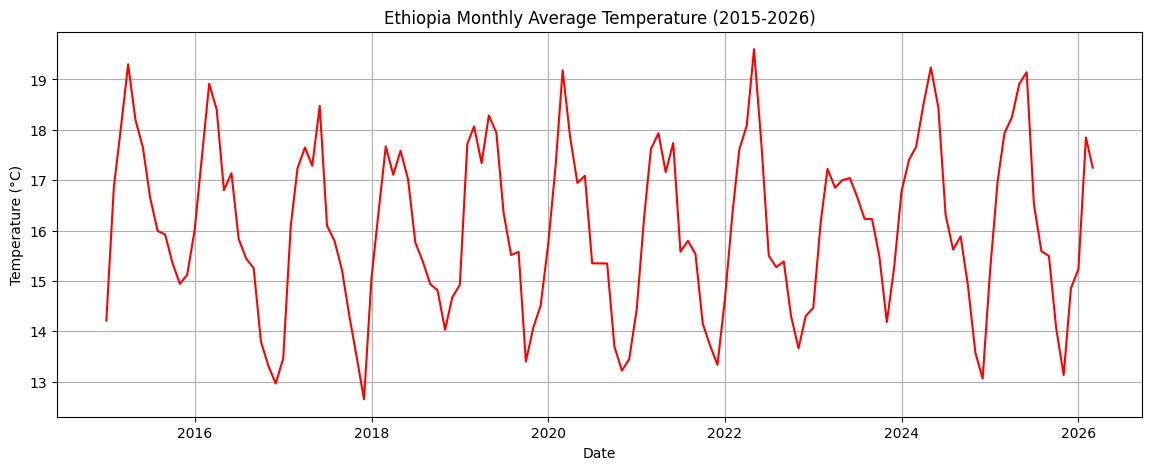

In [30]:
monthly = df.groupby(['Year','Month'])['T2M'].mean().reset_index()
monthly['Date'] = pd.to_datetime(monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str))

plt.figure(figsize=(14,5))
plt.plot(monthly['Date'], monthly['T2M'], color='red')
plt.title('Ethiopia Monthly Average Temperature (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

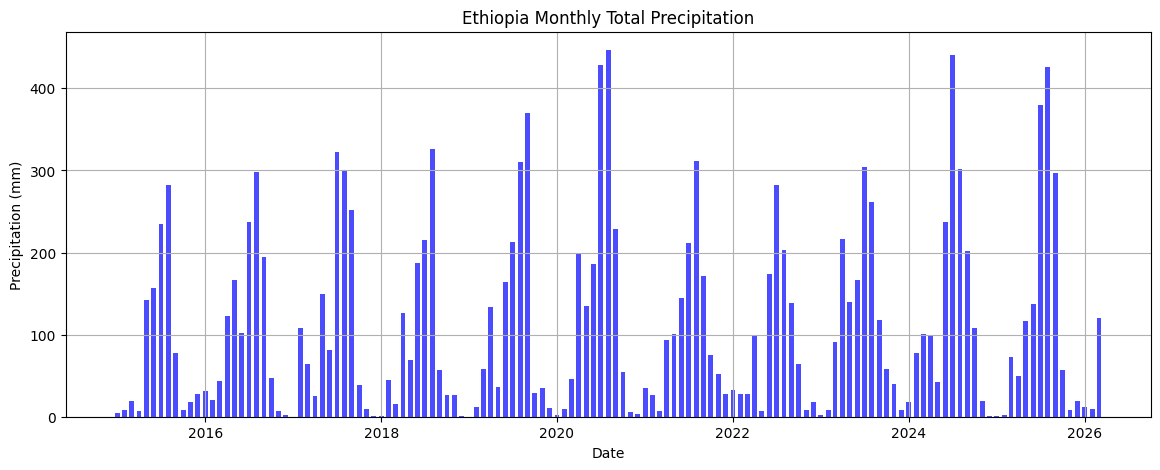

In [31]:
precip = df.groupby(['Year','Month'])['PRECTOTCORR'].sum().reset_index()
precip['Date'] = pd.to_datetime(precip['Year'].astype(str) + '-' + precip['Month'].astype(str))

plt.figure(figsize=(14,5))
plt.bar(precip['Date'], precip['PRECTOTCORR'], width=20, color='blue', alpha=0.7)
plt.title('Ethiopia Monthly Total Precipitation')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.grid(True)
plt.show()

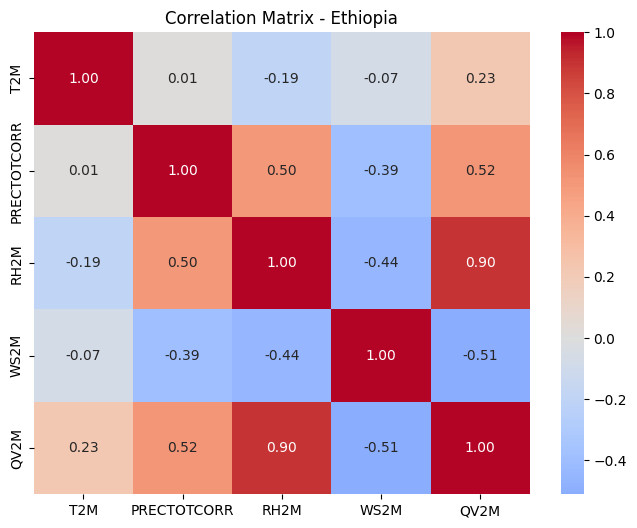

In [32]:
corr = df[['T2M','PRECTOTCORR','RH2M','WS2M','QV2M']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Ethiopia')
plt.show()

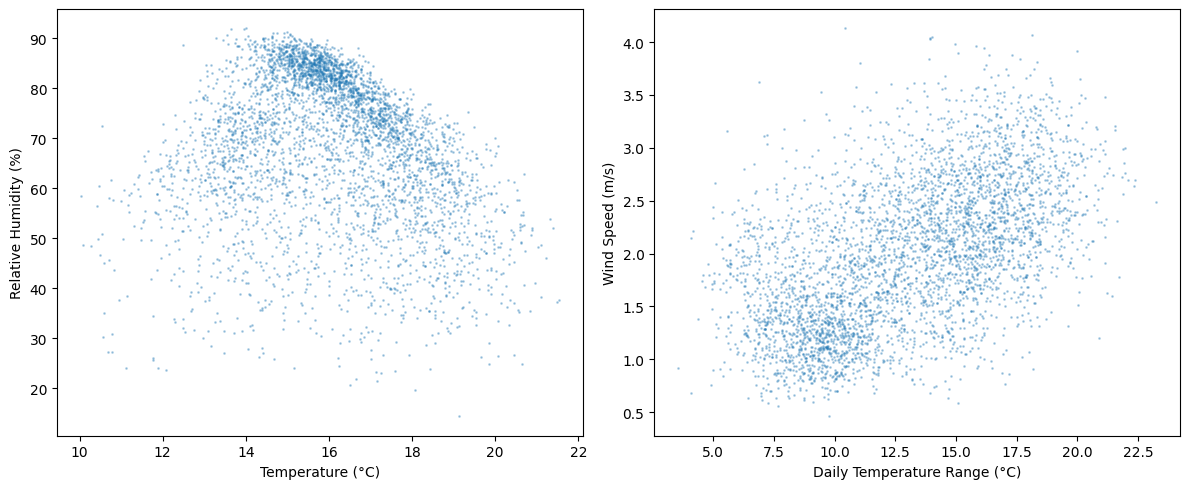

In [33]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.3, s=1)
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, s=1)
axes[1].set_xlabel('Daily Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')
plt.tight_layout()
plt.show()

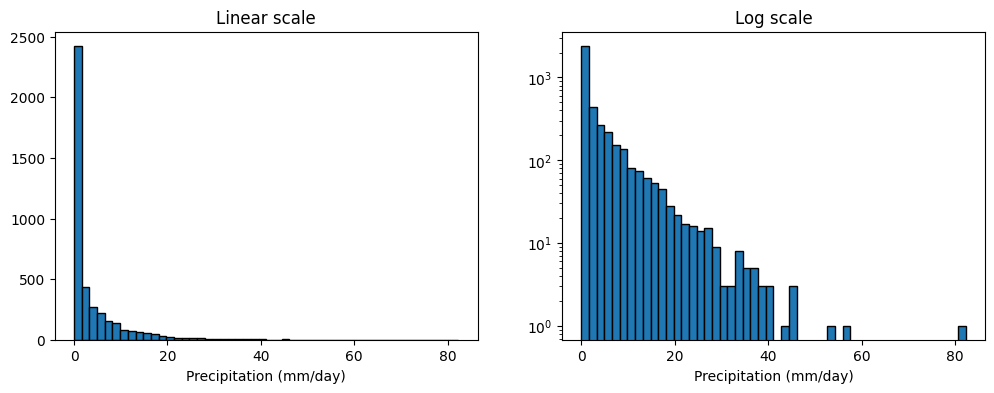

In [34]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(df['PRECTOTCORR'], bins=50, edgecolor='black')
axes[0].set_title('Linear scale')
axes[0].set_xlabel('Precipitation (mm/day)')
axes[1].hist(df['PRECTOTCORR'], bins=50, edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_title('Log scale')
axes[1].set_xlabel('Precipitation (mm/day)')
plt.show()

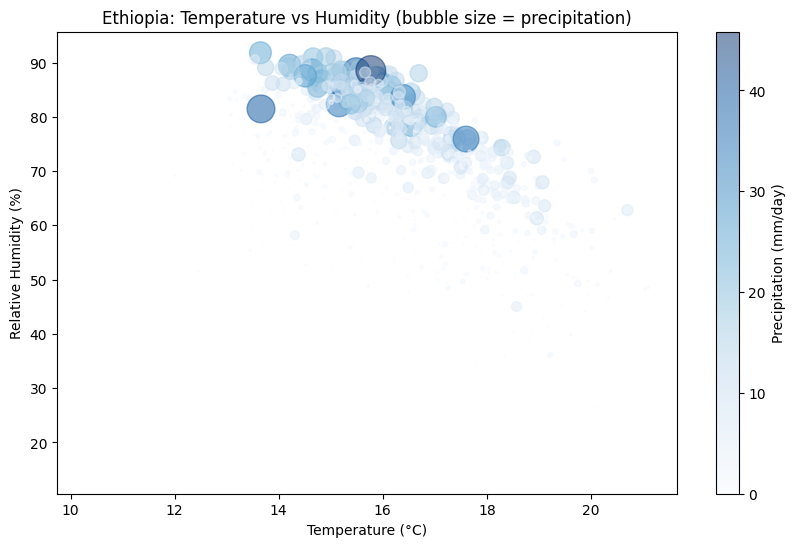

In [35]:
sample = df.sample(min(1000, len(df)))
plt.figure(figsize=(10,6))
sc = plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*10, alpha=0.5, c=sample['PRECTOTCORR'], cmap='Blues')
plt.colorbar(sc, label='Precipitation (mm/day)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Ethiopia: Temperature vs Humidity (bubble size = precipitation)')
plt.show()